# ACT Model Benchmark: CPU vs GPU vs LEM

In [ ]:
import time
import threading
import gc
import os
import sys
import numpy as np
import cupy as cp
import psutil
import mne

sys.path.append("../..")
import act as act_cpu_mod
import act_gpu_cuda   as act_gpu_mod
import act_lem as act_lem_mod

In [2]:
# ── SETTINGS ──────────────────────────────────────────────────────────────────
FS           = 256
EPOCH_LENGTH = 2 * FS          # 512 samples
ORDER        = 10
NUM_EPOCHS   = 20              # transforms per repeat
NUM_REPEATS  = 5               # independent repeats
EEG_CHANNELS = ["HB_1"]

fc_info    = (0.5, 15,  0.5)
logDt_info = (-4,   1,  0.5)
c_info     = (-10,  10, 0.5)
tc_info    = (0, EPOCH_LENGTH, 16)

COMMON_KWARGS = dict(
    FS=FS, length=EPOCH_LENGTH,
    tc_info=tc_info, fc_info=fc_info,
    logDt_info=logDt_info, c_info=c_info,
    mute=True,
)

LEM_KWARGS = dict(
    order=ORDER,
    refine_levels=2,
    top_k=4,
    radius_steps=2,
    coarse_range=[[0, EPOCH_LENGTH], [0.5, 15.0], [-4.0, 1.0], [-10.0, 10.0]],
    step_size=[
        (64, 2.0, 2.0, 5.0),
        (32, 1.0, 1.0, 2.5),
        (16, 0.5, 0.5, 0.5),
    ],
)

In [ ]:
# ── LOAD & PREPROCESS EEG ─────────────────────────────────────────────────────
edf_path = os.path.join(os.getcwd(), '../Testing Scripts/Data/sub-1_task-Sleep_acq-headband_eeg.edf')
raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
raw.pick_channels(EEG_CHANNELS)
raw.notch_filter(freqs=50)
raw.filter(l_freq=0.1, h_freq=20.0, verbose=False)
data = raw.get_data().T

# Slice epochs
total_epochs = data.shape[0] // EPOCH_LENGTH
epochs_cpu = [
    data[i*EPOCH_LENGTH:(i+1)*EPOCH_LENGTH, 0].astype(np.float32)
    for i in range(min(total_epochs, NUM_EPOCHS + 1))  # +1 for warmup
]
epochs_gpu = [cp.asarray(e) for e in epochs_cpu]

print(f"Epochs prepared: {len(epochs_cpu)} × {EPOCH_LENGTH} samples")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1691 samples (6.605 s)

Epochs prepared: 21 × 512 samples


In [4]:
# ── MEMORY MONITOR ────────────────────────────────────────────────────────────
class MemMonitor:
    """Samples CPU and GPU memory at fixed intervals in a background thread."""
    def __init__(self, interval=0.05):
        self.interval = interval
        self._proc = psutil.Process(os.getpid())
        self._stop = threading.Event()
        self._thread = None
        self.cpu_mb: list = []
        self.gpu_mb: list = []

    def _run(self):
        while not self._stop.is_set():
            self.cpu_mb.append(self._proc.memory_info().rss / 1024**2)
            self.gpu_mb.append(cp.get_default_memory_pool().used_bytes() / 1024**2)
            time.sleep(self.interval)

    def start(self):
        self.cpu_mb, self.gpu_mb = [], []
        self._stop.clear()
        self._thread = threading.Thread(target=self._run, daemon=True)
        self._thread.start()

    def stop(self):
        self._stop.set()
        self._thread.join()
        # final sample
        self.cpu_mb.append(self._proc.memory_info().rss / 1024**2)
        self.gpu_mb.append(cp.get_default_memory_pool().used_bytes() / 1024**2)

    @property
    def peak_cpu(self): return max(self.cpu_mb) if self.cpu_mb else 0.0
    @property
    def peak_gpu(self): return max(self.gpu_mb) if self.gpu_mb else 0.0
    @property
    def peak_combined(self): return max(c+g for c,g in zip(self.cpu_mb, self.gpu_mb)) if self.cpu_mb else 0.0


def gpu_sync():
    """Block until all pending GPU work is done."""
    cp.cuda.Stream.null.synchronize()

def reset_memory():
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()

In [5]:
# ── BENCHMARK FUNCTION ────────────────────────────────────────────────────────
def benchmark(name, build_fn, transform_fn, epochs, is_gpu=False, lem_kwargs=None):
    """
    Runs NUM_REPEATS independent repeats. Each repeat:
      1. Builds the model (timed separately)
      2. Warmup: runs 1 untimed transform
      3. Timed: runs NUM_EPOCHS transforms with proper GPU sync
    Returns per-epoch times, build times, norm residues, and peak memory.
    """
    print(f"\n{'='*50}\n{name}\n{'='*50}")

    all_build_times  = []
    all_epoch_times  = []
    all_norm_residue = []
    all_peak_cpu     = []
    all_peak_gpu     = []
    all_peak_combined= []
    all_cpu_traces = []
    all_gpu_traces = []

    for r in range(NUM_REPEATS):
        print(f"  repeat {r+1}/{NUM_REPEATS}")    
        reset_memory()
        warm_model = build_fn()
        if lem_kwargs:
            _ = transform_fn(warm_model, epochs[0], **lem_kwargs)
        else:
            _ = transform_fn(warm_model, epochs[0])
        if is_gpu: gpu_sync()
        reset_memory()  # clear again after warmup
        mon = MemMonitor(interval=0.01)
        mon.start()

        # ── BUILD ──
        t0 = time.perf_counter()
        model = build_fn()
        if is_gpu: gpu_sync()
        t_build = time.perf_counter() - t0
        all_build_times.append(t_build)

        # ── WARMUP (epoch 0, untimed) ──
        if lem_kwargs:
            _ = transform_fn(model, epochs[0], **lem_kwargs)
        else:
            _ = transform_fn(model, epochs[0])
        if is_gpu: gpu_sync()

        # ── TIMED TRANSFORMS ──
        epoch_times  = []
        norm_residues= []

        for i, seg in enumerate(epochs[1:NUM_EPOCHS+1]):
            t0 = time.perf_counter()
            if lem_kwargs:
                out = transform_fn(model, seg, **lem_kwargs)
            else:
                out = transform_fn(model, seg)
            if is_gpu: gpu_sync()
            elapsed = time.perf_counter() - t0

            norm = out["norm_residue"]
            if isinstance(norm, cp.ndarray): norm = norm.get()
            norm = float(np.squeeze(norm))

            epoch_times.append(elapsed)
            norm_residues.append(norm)

        mon.stop()

        all_epoch_times.append(epoch_times)
        all_norm_residue.append(norm_residues)
        all_peak_cpu.append(mon.peak_cpu)
        all_peak_gpu.append(mon.peak_gpu)
        all_peak_combined.append(mon.peak_combined)
        all_cpu_traces.append(mon.cpu_mb)
        all_gpu_traces.append(mon.gpu_mb)

    # ── AGGREGATE ──
    flat_times = [t for rep in all_epoch_times for t in rep]
    flat_norms = [n for rep in all_norm_residue for n in rep]

    return {
        "epoch_mean":     np.mean(flat_times),
        "epoch_std":      np.std(flat_times),
        "build_mean":     np.mean(all_build_times),
        "build_std":      np.std(all_build_times),
        "norm_mean":      np.mean(flat_norms),
        "norm_std":       np.std(flat_norms),
        "peak_cpu_mean":  np.mean(all_peak_cpu),
        "peak_gpu_mean":  np.mean(all_peak_gpu),
        "peak_comb_mean": np.mean(all_peak_combined),
        # raw for plotting
        "all_epoch_times":   all_epoch_times,
        "all_build_times":   all_build_times,
        "all_norm_residue":  all_norm_residue,
        "all_peak_cpu":      all_peak_cpu,
        "all_peak_gpu":      all_peak_gpu,
        "all_peak_combined": all_peak_combined,
        "all_cpu_traces": all_cpu_traces,
        "all_gpu_traces": all_gpu_traces,
    }

In [6]:
# ── RUN ALL MODELS ────────────────────────────────────────────────────────────
results = {}

# CPU
results["CPU"] = benchmark(
    name        = "CPU",
    build_fn    = lambda: act_cpu_mod.ACT(**COMMON_KWARGS, force_regenerate=True),
    transform_fn= lambda m, seg: m.transform(seg, order=ORDER),
    epochs      = epochs_cpu,
    is_gpu      = False,
)

# GPU (cupy hybrid)
results["GPU"] = benchmark(
    name        = "GPU",
    build_fn    = lambda: act_gpu_mod.ACT(**COMMON_KWARGS, hybrid=True, force_regenerate=True),
    transform_fn= lambda m, seg: m.transform(seg, order=ORDER),
    epochs      = epochs_gpu,
    is_gpu      = True,
)
# cp.cuda.set_allocator(cp.cuda.MemoryPool().malloc) 
# LEM
results["LEM"] = benchmark(
    name        = "LEM",
    build_fn    = lambda: act_lem_mod.ACT_LEM(**COMMON_KWARGS),
    transform_fn= lambda m, seg, **kw: m.transform(seg, **kw),
    epochs      = epochs_gpu,
    is_gpu      = True,
    lem_kwargs  = LEM_KWARGS,
)


CPU
  repeat 1/5
Dictionary length: 371200
Dictionary length: 371200
  repeat 2/5
Dictionary length: 371200
Dictionary length: 371200
  repeat 3/5
Dictionary length: 371200
Dictionary length: 371200
  repeat 4/5
Dictionary length: 371200
Dictionary length: 371200
  repeat 5/5
Dictionary length: 371200
Dictionary length: 371200

GPU
  repeat 1/5
CPU cores: 32
GPU Devices detected: 1
Hybrid mode: True
Unified memory: False
Dictionary length: 371200
Generating dictionary on CPU...
Dictionary Generated.
CPU cores: 32
GPU Devices detected: 1
Hybrid mode: True
Unified memory: False
Dictionary length: 371200
Generating dictionary on CPU...
Dictionary Generated.
  repeat 2/5
CPU cores: 32
GPU Devices detected: 1
Hybrid mode: True
Unified memory: False
Dictionary length: 371200
Generating dictionary on CPU...
Dictionary Generated.
CPU cores: 32
GPU Devices detected: 1
Hybrid mode: True
Unified memory: False
Dictionary length: 371200
Generating dictionary on CPU...
Dictionary Generated.
  repea

In [7]:
# ── SUMMARY TABLE ─────────────────────────────────────────────────────────────
W = 110
print(f"\n{'='*W}")
print(f"{'Model':<6} {'Build (s)':>14} {'Epoch (s)':>22} {'Norm Res':>18} {'Peak CPU MB':>13} {'Peak GPU MB':>13} {'Peak Total MB':>14}")
print(f"{'-'*W}")
for name, r in results.items():
    print(
        f"{name:<6} "
        f"{r['build_mean']:>7.3f} ± {r['build_std']:<6.3f} "
        f"{r['epoch_mean']:>9.4f} ± {r['epoch_std']:<9.4f} "
        f"{r['norm_mean']:>8.4f} ± {r['norm_std']:<7.4f} "
        f"{r['peak_cpu_mean']:>13.1f} "
        f"{r['peak_gpu_mean']:>13.1f} "
        f"{r['peak_comb_mean']:>14.1f}"
    )
print(f"{'='*W}")
print(f"\nSettings: {NUM_EPOCHS} epochs × {NUM_REPEATS} repeats, epoch_length={EPOCH_LENGTH}, order={ORDER}")
print(f"Warmup: 1 untimed call per repeat. GPU sync: cp.cuda.Stream.null.synchronize() after every transform.")


Model       Build (s)              Epoch (s)           Norm Res   Peak CPU MB   Peak GPU MB  Peak Total MB
--------------------------------------------------------------------------------------------------------------
CPU      7.009 ± 0.201     0.1447 ± 0.0127      0.0790 ± 0.0213         2622.9           0.0         2623.0
GPU      7.302 ± 0.149     0.0253 ± 0.0081      0.0790 ± 0.0213         2709.7        2045.9         4755.6
LEM      0.000 ± 0.000    11.4632 ± 0.8404      0.0942 ± 0.0260          978.3          21.3          999.4

Settings: 20 epochs × 5 repeats, epoch_length=512, order=10
Warmup: 1 untimed call per repeat. GPU sync: cp.cuda.Stream.null.synchronize() after every transform.


/tmp/ipykernel_6158/4135032445.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=names, patch_artist=True)
/tmp/ipykernel_6158/4135032445.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(data_norm, labels=names, patch_artist=True)


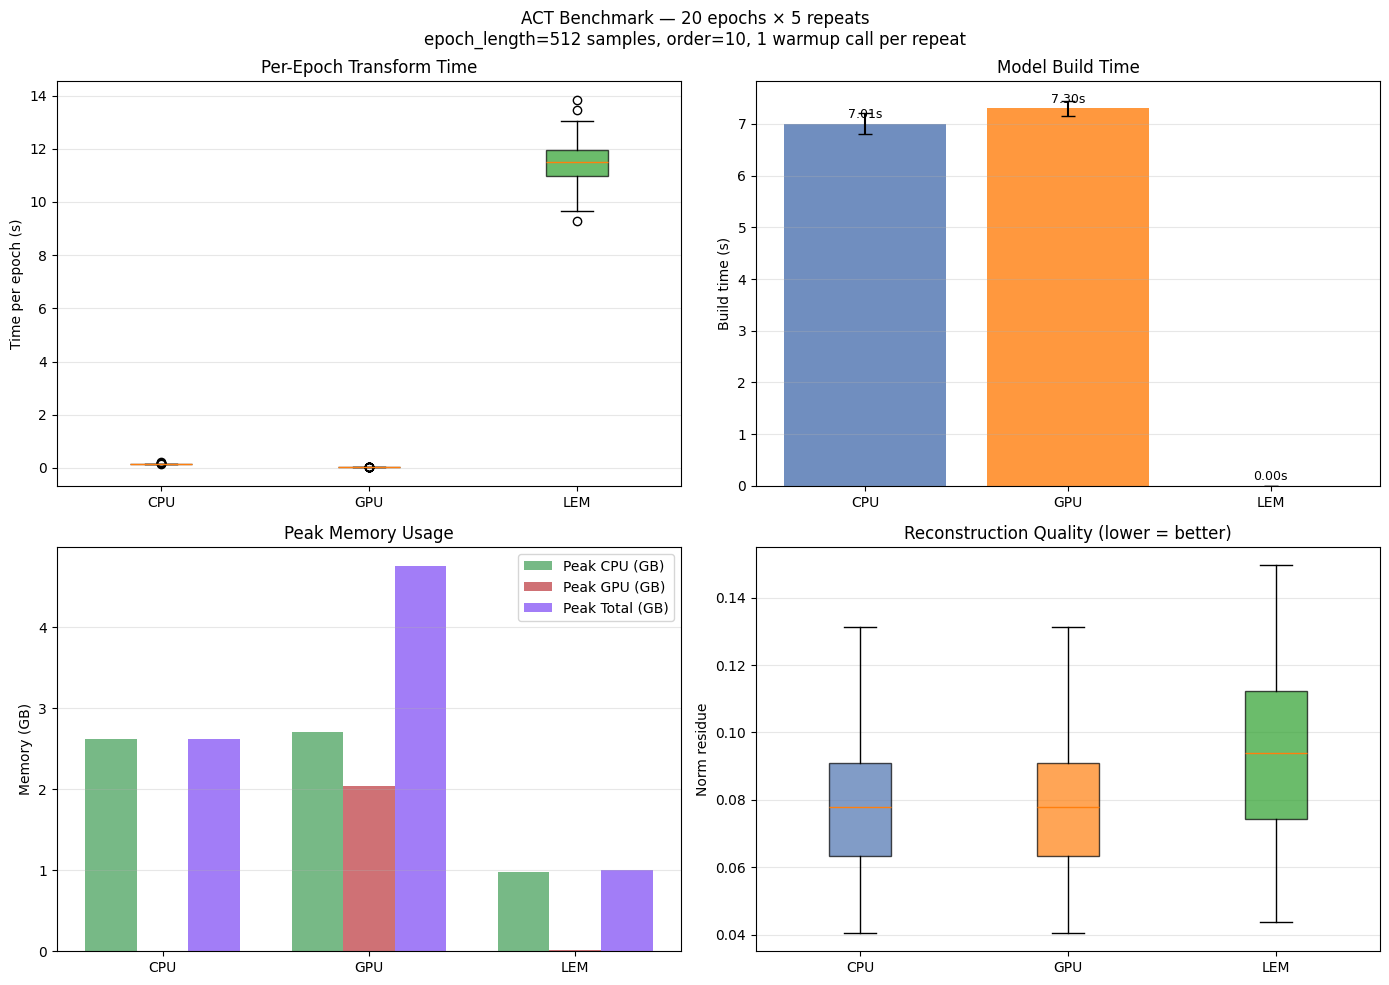

In [8]:
# ── PLOTS ─────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

COLORS = {"CPU": "#4C72B0", "GPU": "#ff7f0e", "LEM": "#2ca02c"}
names  = list(results.keys())
x      = np.arange(len(names))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"ACT Benchmark — {NUM_EPOCHS} epochs × {NUM_REPEATS} repeats\n"
    f"epoch_length={EPOCH_LENGTH} samples, order={ORDER}, 1 warmup call per repeat",
    fontsize=12
)

# ── Panel 1: per-epoch time (box plot across all repeats) ──
ax = axes[0, 0]
data_box = [np.array([t for rep in results[n]["all_epoch_times"] for t in rep]) for n in names]
bp = ax.boxplot(data_box, labels=names, patch_artist=True)
for patch, name in zip(bp['boxes'], names):
    patch.set_facecolor(COLORS[name])
    patch.set_alpha(0.7)
ax.set_ylabel("Time per epoch (s)")
ax.set_title("Per-Epoch Transform Time")
ax.grid(True, alpha=0.3, axis="y")

# ── Panel 2: build time ──
ax = axes[0, 1]
build_means = [results[n]["build_mean"] for n in names]
build_stds  = [results[n]["build_std"]  for n in names]
bars = ax.bar(x, build_means, yerr=build_stds, capsize=5,
              color=[COLORS[n] for n in names], alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("Build time (s)")
ax.set_title("Model Build Time")
ax.grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, build_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}s", ha="center", va="bottom", fontsize=9)

# ── Panel 3: peak memory breakdown ──
ax = axes[1, 0]
width = 0.25
peak_cpu  = [results[n]["peak_cpu_mean"]/1000  for n in names]
peak_gpu  = [results[n]["peak_gpu_mean"]/1000  for n in names]
peak_comb = [results[n]["peak_comb_mean"]/1000 for n in names]
ax.bar(x - width, peak_cpu,  width, label="Peak CPU (GB)", color="#55A868", alpha=0.8)
ax.bar(x,         peak_gpu,  width, label="Peak GPU (GB)", color="#C44E52", alpha=0.8)
ax.bar(x + width, peak_comb, width, label="Peak Total (GB)",color="#8B5CF6", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("Memory (GB)")
ax.set_title("Peak Memory Usage")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

# ── Panel 4: norm residue ──
ax = axes[1, 1]
data_norm = [np.array([n for rep in results[nm]["all_norm_residue"] for n in rep]) for nm in names]
bp2 = ax.boxplot(data_norm, labels=names, patch_artist=True)
for patch, name in zip(bp2['boxes'], names):
    patch.set_facecolor(COLORS[name])
    patch.set_alpha(0.7)
ax.set_ylabel("Norm residue")
ax.set_title("Reconstruction Quality (lower = better)")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

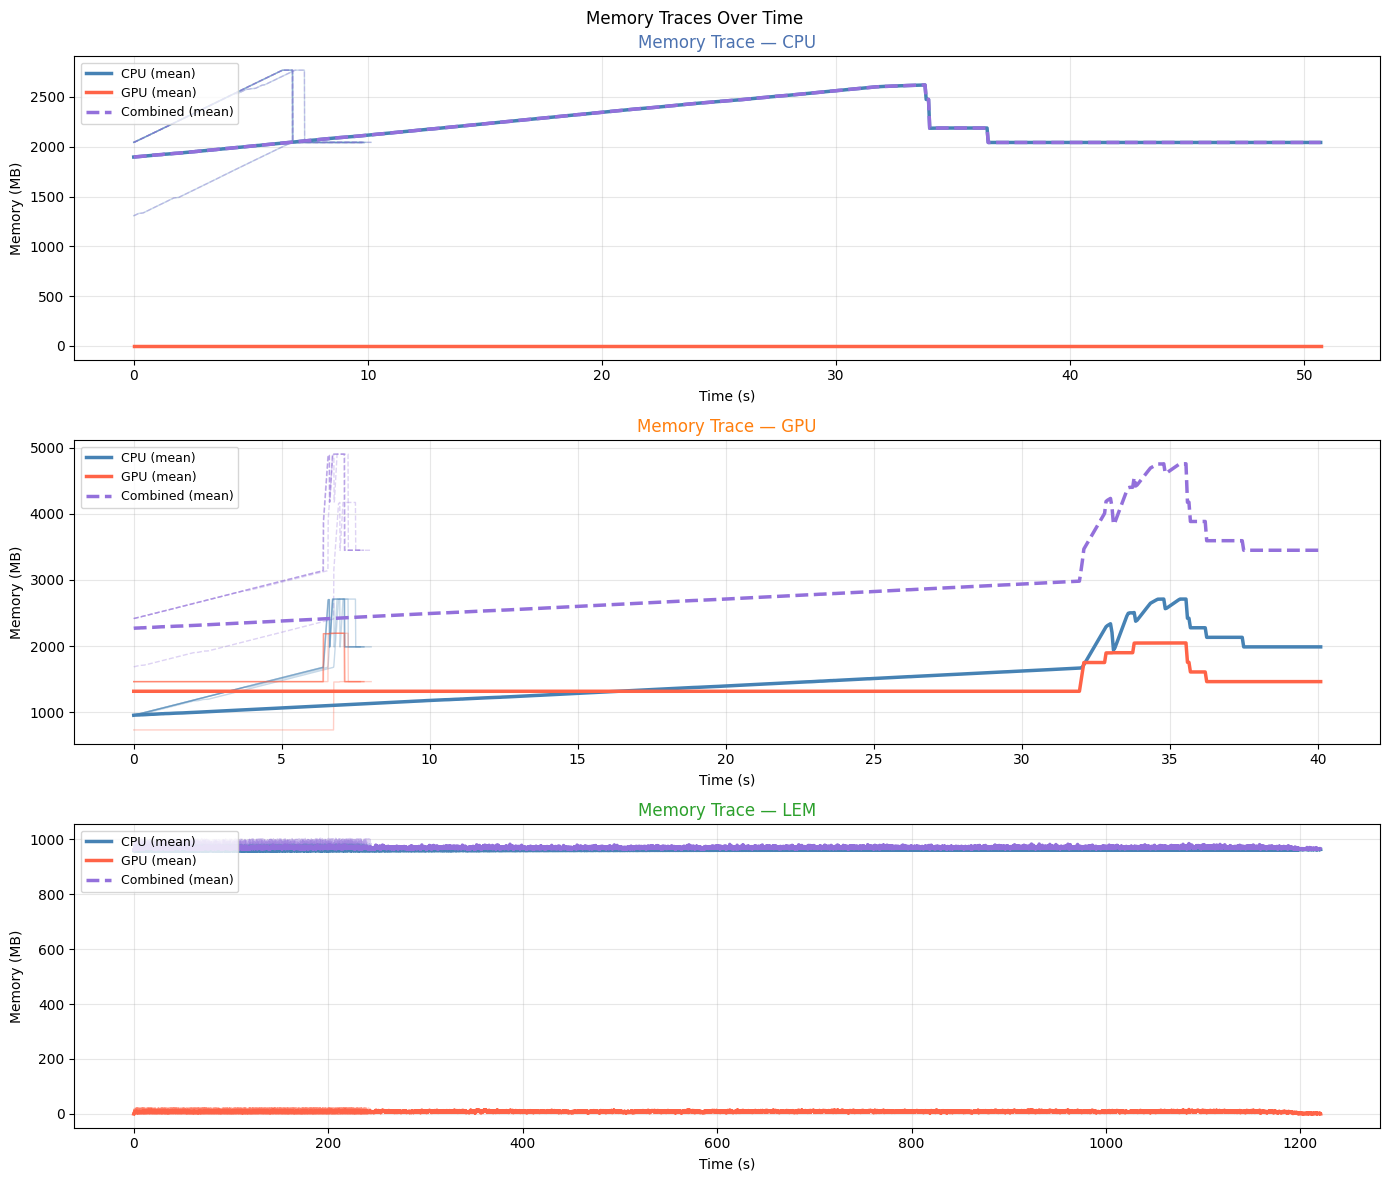

In [9]:
# ── PLOT 2: Memory Traces ──────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(len(results), 1, figsize=(14, 4 * len(results)), sharex=False)
fig2.suptitle("Memory Traces Over Time", fontsize=12)

if len(results) == 1:
    axes2 = [axes2]

for ax, name in zip(axes2, names):
    r = results[name]
    color = COLORS[name]

    for rep_idx, (cpu, gpu) in enumerate(zip(r["all_cpu_traces"], r["all_gpu_traces"])):
        t        = np.arange(len(cpu)) * 0.01          # interval=0.05
        combined = [c + g for c, g in zip(cpu, gpu)]
        alpha    = max(0.3, 1.0 / len(r["all_cpu_traces"]))

        ax.plot(t, cpu,       color="steelblue",    alpha=alpha, linewidth=1)
        ax.plot(t, gpu,       color="tomato",        alpha=alpha, linewidth=1)
        ax.plot(t, combined,  color="mediumpurple",  alpha=alpha, linewidth=1, linestyle="--")

    # bold mean traces across repeats
    max_len   = max(len(c) for c in r["all_cpu_traces"])
    mean_cpu  = np.mean([np.pad(c, (0, max_len - len(c)), constant_values=c[-1]) for c in r["all_cpu_traces"]], axis=0)
    mean_gpu  = np.mean([np.pad(g, (0, max_len - len(g)), constant_values=g[-1]) for g in r["all_gpu_traces"]], axis=0)
    mean_comb = mean_cpu + mean_gpu
    t_mean    = np.arange(max_len) * 0.05

    ax.plot(t_mean, mean_cpu,  color="steelblue",   linewidth=2.5, label="CPU (mean)")
    ax.plot(t_mean, mean_gpu,  color="tomato",       linewidth=2.5, label="GPU (mean)")
    ax.plot(t_mean, mean_comb, color="mediumpurple", linewidth=2.5, linestyle="--", label="Combined (mean)")

    ax.set_title(f"Memory Trace — {name}", color=color)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Memory (MB)")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()